## 1. Importación de librerías y Lectura de datos

Primero importamos las librerías necesarias para la lectura de los datos, para luego subir el .csv a un dataframe nombrado como df

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv") # Almacenamos el dataset dentro de la variable df
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Inspección de los datos

Es importante revisar los datos primero para poder saber con qué estamos trabajando.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3. Tratamiento de datos faltantes en el dataset

Primero, generamos un gráfico para poder identificar en donde podemos encontrar los datos faltantes

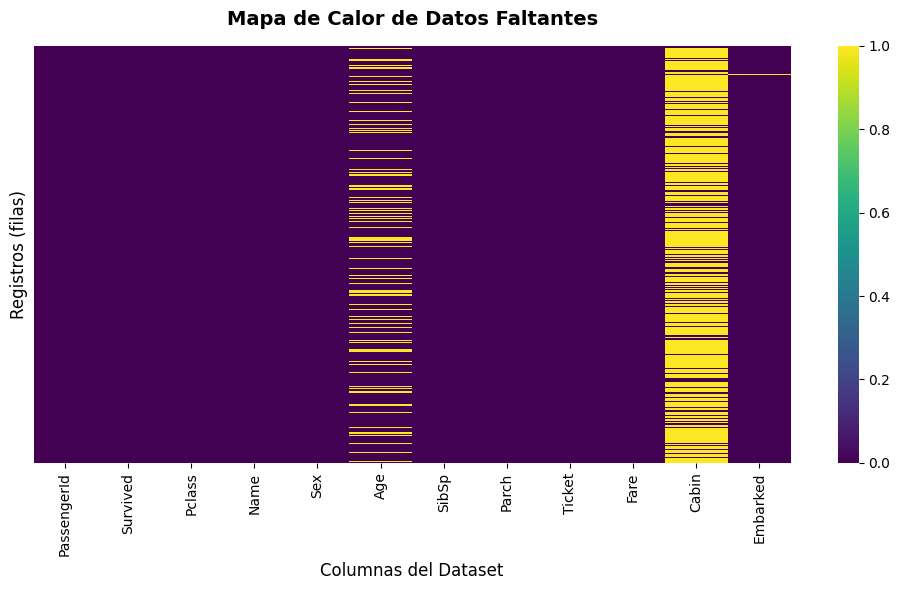

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# - df.isnull() convierte los datos en Booleanos (True si es nulo, False si no)
# - yticklabels=False oculta los números de fila para que se vea limpio
# - cmap='viridis' usa una paleta de alto contraste (amarillo = nulo, morado = completo)
# - cbar=True muestra la barra de escala lateral
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=ax)

ax.set_title('Mapa de Calor de Datos Faltantes', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Columnas del Dataset', fontsize=12)
ax.set_ylabel('Registros (filas)', fontsize=12)

plt.tight_layout()

# Usamos .savefig() para almacenar el gráfico y analizarlo más tarde 
plt.savefig('mapa_calor_faltantes.png', dpi=300)

Utilizamos un mapa de calor binario donde el color claro representa la ausencia de información. Esto nos permite ver no solo la cantidad, sino la dispersión de los datos nulos de forma rápida